In [1]:
%cd ../.
import sys
sys.path.append('../keys'); # sys.path.append('./.')

/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking


In [26]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
import prolif as plf
from glob import glob
import meeko
import subprocess as sub
from vina import Vina
import time

# user defined modules
import python.Rdkit_tools as rdkit_tools
import python.Molecule as M
from python.MolViz3D import MolViz3D


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FUNCTIONS

In [77]:
def get_interactions_coords(prot_pdb, lig_sdf):
    """
    Extract interaction coordinates between protein and ligand using ProLIF.
    
    Returns:
        list of dicts with keys: 'residue', 'type', 'ligand_coords', 'protein_coords', 'distance'
    """
    ## read protein and ligand with rdkit:
    rdkit_prot = Chem.MolFromPDBFile(prot_pdb, removeHs=False)
    
    ## Convert to ProLIF molecules
    plf_protein = plf.Molecule(rdkit_prot)
    plf_ligand = plf.sdf_supplier(lig_sdf)[0]

    ## compute fingerprint
    fp_count = plf.Fingerprint(count=True)
    fp_count.run_from_iterable([plf_ligand], plf_protein)

    ## IMPORTANT: Use ProLIF ligand molecule for coords (it may have added hydrogens)
    ## but use original protein for coords (parent_indices match original)
    lig_conf = plf_ligand.GetConformer()
    prot_conf = rdkit_prot.GetConformer()

    ## get interaction coordinates:
    interactions = []
    
    for (lig_res, prot_res), interaction_types in fp_count.ifp[0].items():
        residue_name = f"{prot_res.name}{prot_res.number}"
        if prot_res.chain:
            residue_name += f":{prot_res.chain}"
        
        for interaction_type, interaction_list in interaction_types.items():
            for interaction in interaction_list:
                # For ligand: use 'indices' (local to ProLIF molecule)
                # For protein: use 'parent_indices' (global in original protein)
                lig_indices = interaction['indices']['ligand']
                prot_indices = interaction['parent_indices']['protein']
                
                # Calculate centroid of ligand atoms (from ProLIF molecule)
                lig_coords = np.array([
                    list(lig_conf.GetAtomPosition(idx)) for idx in lig_indices
                ]).mean(axis=0)
                
                # Calculate centroid of protein atoms (from original molecule)
                prot_coords = np.array([
                    list(prot_conf.GetAtomPosition(idx)) for idx in prot_indices
                ]).mean(axis=0)
                
                interactions.append({
                    'residue': residue_name,
                    'type': interaction_type,
                    'ligand_coords': lig_coords.tolist(),
                    'protein_coords': prot_coords.tolist(),
                    'distance': interaction['distance']
                })

    return interactions

## to be moved somewhere else
def prepare_ligand_pdbqt_from_smiles(smiles, single=False):
    """
    As the name suggest does all the preparation for you
    from the smiles string
    :return str pqbdt
    """
    # Convert SMILES to 3D structure
    if single:
        mol = Chem.MolFromSmiles(smiles)
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        AllChem.UFFOptimizeMolecule(mol)

        # prepare pdbqt from meeko
        preparator = meeko.MoleculePreparation()
        mol_setups = preparator.prepare(mol)
        pdbqts = [meeko.PDBQTWriterLegacy.write_string(mol_setups[0])[0]]
    else:
        # find whether glutarimide or DHU
        mol = Chem.MolFromSmiles(smiles)

        # generate multiple conformers:
        m, c_ids = clustering_coords(mol, M=100, N=10, how='etkdg')

        # convert Molecules:
        pdbqts = []
        for c_id in c_ids:

            mol_conf = Chem.Mol(m)
            mol_conf.RemoveAllConformers()
            mol_conf.AddConformer(m.GetConformer(c_id), assignId=True)
            # print(Chem.SDWriter.GetText(mol_conf))

            mol_conf = Chem.AddHs(mol_conf)  # Add hydrogens

            # prepare pdbqt from meeko
            preparator = meeko.MoleculePreparation()
            mol_setups = preparator.prepare(mol_conf)
            # print(meeko.PDBQTWriterLegacy.write_string(mol_setups[0]))
            pdbqt = meeko.PDBQTWriterLegacy.write_string(mol_setups[0])[0]
            # print(pdbqt)

            pdbqts.append(pdbqt)

    return pdbqts

def prepare_ligand_pdbqt_from_sdf(sdf_path):
    """
    Does what the name suggestes
    """
    # print(sdf_path)
    suppl = Chem.SDMolSupplier(sdf_path)
    mol = suppl[0]
    mol = Chem.AddHs(mol, addCoords=True)

    ## prepare pdbqt from meeko
    preparator = meeko.MoleculePreparation()
    mol_setups = preparator.prepare(mol)
    pdbqts = [meeko.PDBQTWriterLegacy.write_string(mol_setups[0])[0]]

    return pdbqts[0]

def prepare_ligand_pdbqt_from_mol(mol):
    """
    Does what the name suggestes
    """
    mol = Chem.AddHs(mol, addCoords=True)

    ## prepare pdbqt from meeko
    preparator = meeko.MoleculePreparation()
    mol_setups = preparator.prepare(mol)
    pdbqts = [meeko.PDBQTWriterLegacy.write_string(mol_setups[0])[0]]

    return pdbqts[0]


# MAIN

#### 1. Simple display of ligand and protein structures using MolViz3D class

In [82]:
## import protein and ligand molecules
# from (https://www.kaggle.com/datasets/madukacharles/pdbbind-protein-ligand-binding-affinity-dataset?resource=download)
c_path = '/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core'
fnames  = [x.split('/')[-1] for x in glob(c_path+'/*')]

fname = '1hvr' #fnames[17]
print(f'>> working with {fname}')

cm     = M.Molecule()
cm_f   = f'{c_path}/{fname}/{fname}_ligand.sdf'
prot_f = f'{c_path}/{fname}/{fname}_protein.pdb'
pock_f = f'{c_path}/{fname}/{fname}_pocket.pdb'
# get smiles from ligand
mol = rdkit_tools.get_mol_from_structure(cm_f)
smiles = Chem.MolToSmiles(mol)
print('>>',smiles)
prot_M = M.Molecule()
prot_M.import_pdb(prot_f)
# cm.import_sdf('/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core/1a30/1a30_ligand.sdf')


>> working with 1hvr
>> O=C1N(Cc2ccc3ccccc3c2)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H](Cc2ccccc2)N1Cc1ccc2ccccc2c1


In [83]:
## Visualizer
M3D = MolViz3D()
M3D.show_ligand(cm_f,radius=0.12)
M3D.show_protein_single_color(prot_f,color='white')
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.1,showHydrogens=True)
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.15,showHydrogens=False)
M3D.view.zoomTo({'model': 0}) # # M3D.view.zoomTo(viewer=(100,0))
M3D.view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### 2. Visualizer using Prolif

In [49]:
# # Test the function
# prot_f = '/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/test/protein.pdb'
# cm_f   = '/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/test/ligand.sdf'
# interactions = get_interactions_coords(prot_f, cm_f)
# print(f"Found {len(interactions)} interactions\n")

# # Show a few examples
# for i, inter in enumerate(interactions[:5]):
#     print(f"{i+1}. {inter['type']} with {inter['residue']}")
#     print(f"   Ligand coords:  {[round(c, 2) for c in inter['ligand_coords']]}")
#     print(f"   Protein coords: {[round(c, 2) for c in inter['protein_coords']]}")
#     print(f"   Distance: {inter['distance']:.2f} A\n")

In [50]:
## Visualize profif interactions:
# https://prolif.readthedocs.io/en/latest/notebooks/pdb.html#pdb
## read protein and ligand with rdkit:
rdkit_prot        = Chem.MolFromPDBFile(prot_f, removeHs=False)
rdkit_protein_mol = plf.Molecule(rdkit_prot)
ligand_mol        = plf.sdf_supplier(cm_f)[0]
# display ligand
# plf.display_residues(ligand_mol, size=(400, 200))

## compute fingerprint
fp_count = plf.Fingerprint(count=True)
fp_count.run_from_iterable([ligand_mol], rdkit_protein_mol)

## View
view = fp_count.plot_3d(ligand_mol, rdkit_protein_mol, frame=0, display_all=False)
view

100%|██████████| 1/1 [00:00<00:00, 15.97it/s]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### 3. Docking with Autodock Vina

In [ ]:
## Prepare pdbqts for Autodock vina:

# get ligand pdbqt as text
ligand_sdf   = cm_f
if 11 < 3:
    ligand_pdbqt = prepare_ligand_pdbqt_from_sdf(ligand_sdf)
else:
    ligand_pdbqt = prepare_ligand_pdbqt_from_smiles(smiles, single=True)[0]

## Prepare protein pdbqt:
prot = pock_f # prot_f #  
prot_pdbqt = prot + 'qt' # pdbqt path of protein, if using the webapp, please modify this path

if not os.path.exists(prot_pdbqt):
    ## write pdbqt of protein to disk:
    with open(os.devnull, 'wb') as shutup:
        cmd = 'obabel -ipdb ' + prot + ' -O ' + prot_pdbqt + ' -p 7.4 -xr'
        # print(cmd)
        sub.call(cmd, shell=True, stderr=shutup)
else:
    print(prot_pdbqt, 'found')

# get crystal structure to set box parameters:
xtal = M.Molecule()
xtal.import_sdf(cm_f,use_openbabel=True)

# get pdqbt of ligand as text:
lig_M = M.Molecule()
lig_M.import_pdb(ligand_pdbqt, from_text=True)
pdbtxt = lig_M.write_pdb()
outpath = f'/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/output/vina/{fname}_docked.pdbqt'

/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core/3f17/3f17_pocket.pdbqt found


In [ ]:
%%time
## DOCKING
# create pdbqt to extract for A. vina's optimization
try:
    v = Vina(sf_name='vina', cpu=8, verbosity=1)
    v.set_receptor(prot_pdbqt)
    v.set_ligand_from_string(ligand_pdbqt)

    # set box conditions
    box_l = (xtal.rgyr() * 2.857) + 5.0
    v.compute_vina_maps(center=xtal.center(), box_size=[box_l, box_l, box_l])
    print('>> docking', outpath)
    # Dock the ligand
    v.dock(exhaustiveness=8, n_poses=10)
    v.write_poses(outpath, n_poses=10, overwrite=True)
except:
    print('>> could not dock!')

Computing Vina grid ... >> docking /Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/output/vina/3f17_.pdbqt
done.
Performing docking (random seed: 1730692918) ... 
0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
   1      -8.2430     0.0000     0.0000
   2      -8.0059     0.4329     1.5546
   3      -7.9471     2.3102     3.5369
   4      -7.6087     2.3793     3.3949
   5      -7.5692     1.9019     2.3070
   6      -7.4920     1.7270     2.3508
   7      -7.1789     5.0896     8.3984
   8      -6.1240     2.8615     4.6107
   9      -6.0253     3.8831     8.1499
  10      -5.9044     3.6247     8.7729
CPU times: user 29 s, sys: 1.45 s, total: 30.4 s
Wall time: 24 s


In [88]:

dock_df = rdkit_tools.extract_vina_out_pdbqt_txt(outpath,smiref=smiles)
best_pdbqt_mol = dock_df.iloc[0]['mol']
Chem.MolToMolBlock(best_pdbqt_mol)                           

'\n     RDKit          3D\n\n 21 22  0  0  0  0  0  0  0  0999 V2000\n    2.1170   -3.9210    5.8690 N   0  0  0  0  0  0  0  0  0  0  0  0\n    2.2950   -4.0580    4.4230 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.5720   -2.9490    3.7200 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.6800   -3.2240    2.8750 O   0  0  0  0  0  0  0  0  0  0  0  0\n    1.9010   -1.5800    3.9660 N   0  0  0  0  0  0  0  0  0  0  0  0\n    1.5800   -1.0150    5.0320 O   0  0  0  0  0  0  0  0  0  0  0  0\n    1.7930   -5.4770    6.5720 S   0  0  0  0  0  0  0  0  0  0  0  0\n    1.3180   -6.4170    5.5010 O   0  0  0  0  0  0  0  0  0  0  0  0\n    0.7180   -5.3400    7.6160 O   0  0  0  0  0  0  0  0  0  0  0  0\n    3.2630   -6.1270    7.2930 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.2990   -6.4770    8.6480 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.4050   -6.3010    6.5040 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.4730   -6.9860    9.2120 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.5

In [89]:
## Visualizer
M3D = MolViz3D()
M3D.show_ligand(cm_f,radius=0.12)
M3D.show_ligand(best_pdbqt_mol, radius=0.12, colorscheme='orangeCarbon',origin='df')  # Uncomment when dock is defined
M3D.show_protein_single_color(prot_f,color='white')
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.1,showHydrogens=True)
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.15,showHydrogens=False)
M3D.view.zoomTo({'model': 0}) # # M3D.view.zoomTo(viewer=(100,0))
M3D.view.show()

## ligands
# M3D.show_ligand(ref, radius=0.05, colorscheme='whiteCarbon')  # _renum

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [55]:
## Visualize profif interactions:
# https://prolif.readthedocs.io/en/latest/notebooks/pdb.html#pdb
## read protein and ligand with rdkit:
rdkit_prot        = Chem.MolFromPDBFile(prot_f, removeHs=False)
rdkit_protein_mol = plf.Molecule(rdkit_prot)
ligand_mol        = plf.Molecule(best_pdbqt_mol) #plf.sdf_supplier(Chem.MolToMolBlock(best_pdbqt_mol))[0]
# display ligand
# plf.display_residues(ligand_mol, size=(400, 200))

## compute fingerprint
fp_count = plf.Fingerprint(count=True)
fp_count.run_from_iterable([ligand_mol], rdkit_protein_mol)

## View
view = fp_count.plot_3d(ligand_mol, rdkit_protein_mol, frame=0, display_all=False)
view

100%|██████████| 1/1 [00:00<00:00, 17.76it/s]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [34]:
cm_f

'/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core/3f17/3f17_ligand.sdf'

In [73]:
## Building macthing 3d conformers:
# Custom MCS parameters (looser matching)
mcs_params = {
    'ringMatchesRingOnly': False,
    'completeRingsOnly': False,
    'bondCompare': rdFMCS.BondCompare.CompareAny,
    'atomCompare': rdFMCS.AtomCompare.CompareElements,
}

ori = '/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core/3f17/3f17_ligand.sdf'
smi = 'c1ccc(cc1)C(C(N=O)=O)NS(=O)(=O)c2cc(ccc2)C3CNCC3'
try:
    mol_test = Chem.MolFromSmiles(smi)
except:
    print('could not parse smi!')

mol, _, _ = rdkit_tools.generate_conformer_from_reference(
    smi, ori, mcs_params=mcs_params, verbose=False
)


[RDKit] WARNING:[22:45:54] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [78]:
ligand_pdbqt = prepare_ligand_pdbqt_from_mol(mol)

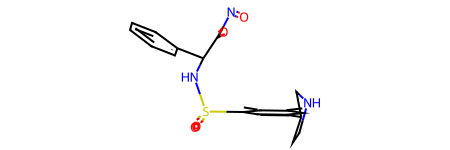

In [74]:
mol

In [75]:
M3D = MolViz3D()
M3D.show_ligand(cm_f,radius=0.12)
M3D.show_ligand(mol, radius=0.15, colorscheme='orangeCarbon',origin='df')  # Uncomment when dock is defined
# M3D.show_protein_single_color(prot_f,color='white')
# M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.1,showHydrogens=True)
# M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.15,showHydrogens=False)
M3D.view.zoomTo({'model': 0}) # # M3D.view.zoomTo(viewer=(100,0))
M3D.view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### 4. Final Docking as prep for webpage

In [84]:
def dock_with_vina(ref_sdf, prot_f, pock_f, outpath, smiles) -> None:
    """
    Peforms docking with Autodock Vina given:
    - ref_sdf: path to reference sdf (for box and conformer generation)
    - prot_f: path to protein pdb file
    - pock_f: path to pocket pdb file
    - outpath: path to save docking results
    - smiles: ligand smiles string
    """
    ## Prepare pdbqts for Autodock vina:
    ## ---------------------------------

    ## first try to generate a structure following stereochemistry of reference
    try:
        print('>> generating conformer from reference sdf')
        mcs_params = {
            'ringMatchesRingOnly': False,
            'completeRingsOnly': False,
            'bondCompare': rdFMCS.BondCompare.CompareAny,
            'atomCompare': rdFMCS.AtomCompare.CompareElements,
        }
        try:
            Chem.MolFromSmiles(smiles)
        except:
            print('> could not parse smi!')

        mol, _, _ = rdkit_tools.generate_conformer_from_reference(
            smiles, ref_sdf, mcs_params=mcs_params, verbose=False)

        ligand_pdbqt = prepare_ligand_pdbqt_from_mol(mol)
    except:
        print('could not generate conformer from reference')
        ligand_pdbqt = prepare_ligand_pdbqt_from_smiles(smiles, single=True)[0]

    ## Prepare protein pdbqt:
    print('>> preparing protein pdbqt')
    prot = pock_f # prot_f #  
    prot_pdbqt = prot + 'qt' # pdbqt path of protein, if using the webapp, please modify this path

    if not os.path.exists(prot_pdbqt):
        ## write pdbqt of protein to disk:
        with open(os.devnull, 'wb') as shutup:
            cmd = 'obabel -ipdb ' + prot + ' -O ' + prot_pdbqt + ' -p 7.4 -xr'
            # print(cmd)
            sub.call(cmd, shell=True, stderr=shutup)
    else:
        print(prot_pdbqt, 'found')

    # get crystal structure to set box parameters:
    xtal = M.Molecule()
    xtal.import_sdf(ref_sdf,use_openbabel=True)

    # get pdqbt of ligand as text:
    lig_M = M.Molecule()
    lig_M.import_pdb(ligand_pdbqt, from_text=True)
    pdbtxt = lig_M.write_pdb()
    

    ## DOCKING
    ## ---------------------------------
    print('>> docking', outpath)
    try:
        v = Vina(sf_name='vina', cpu=8, verbosity=1)
        v.set_receptor(prot_pdbqt)
        v.set_ligand_from_string(ligand_pdbqt)

        # set box conditions
        box_l = (xtal.rgyr() * 2.857) + 5.0
        v.compute_vina_maps(center=xtal.center(), box_size=[box_l, box_l, box_l])
        
        # Dock the ligand
        v.dock(exhaustiveness=16, n_poses=5)
        v.write_poses(outpath, n_poses=5, overwrite=True)
    except:
        print('>> could not dock!')

## import protein and ligand molecules
# from (https://www.kaggle.com/datasets/madukacharles/pdbbind-protein-ligand-binding-affinity-dataset?resource=download)
c_path = '/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core'
fnames  = [x.split('/')[-1] for x in glob(c_path+'/*')]

fname = fnames[17]
print(f'>> working with {fname}')

cm_f    = f'{c_path}/{fname}/{fname}_ligand.sdf'
prot_f  = f'{c_path}/{fname}/{fname}_protein.pdb'
pock_f  = f'{c_path}/{fname}/{fname}_pocket.pdb'
smiles  = Chem.MolToSmiles(rdkit_tools.get_mol_from_structure(cm_f))
outpath = f'/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/output/vina/{fname}_docked.pdbqt'
test_smi= 'c1ccc(cc1)C(C(N=O)=O)NS(=O)(=O)c2cc(ccc2)C3CNCC3'

## run docking
dock_with_vina(cm_f, prot_f, pock_f, outpath, test_smi)

## get best docked pose:
dock_df = rdkit_tools.extract_vina_out_pdbqt_txt(outpath,smiref=test_smi)
best_pdbqt_mol = dock_df.iloc[0]['mol']

## visualize docking results:
M3D = MolViz3D()
M3D.show_ligand(cm_f,radius=0.12)
M3D.show_ligand(best_pdbqt_mol, radius=0.12, colorscheme='orangeCarbon',origin='df')  # Uncomment when dock is defined
M3D.show_protein_single_color(prot_f,color='white')
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.1,showHydrogens=True)
M3D.show_protein_residues(prot_f,style='stick',colorscheme='lightgreyCarbon',radius=0.15,showHydrogens=False)
M3D.view.zoomTo({'model': 0}) # # M3D.view.zoomTo(viewer=(100,0))
M3D.view.show()


>> working with 3f17
>> generating conformer from reference sdf
>> preparing protein pdbqt
/Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/data/v2013-core/3f17/3f17_pocket.pdbqt found
>> docking /Users/giorgiotamo/Desktop/GT/Programming/Lavoro/GitHub/VSDocking/output/vina/3f17_docked.pdbqt
Computing Vina grid ... done.
Performing docking (random seed: 1497482265) ... 
0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
   1       -7.845          0          0
   2       -7.517      2.729      7.739
   3        -7.45      4.305      7.186
   4       -7.439      2.621      3.608
   5       -7.347      4.527      6.801


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# ## time per docking:
# # CPU counts to test
# cpu_counts = [1, 2, 4, 6, 8, 10]
# n_trials = 3

# results = []

# for n_cpu in cpu_counts:
#     times = []
#     for trial in range(n_trials):
#         v = Vina(sf_name='vina', cpu=n_cpu, verbosity=0)  # verbosity=0 to reduce output
#         v.set_receptor(prot_pdbqt)
#         v.set_ligand_from_string(ligand_pdbqt)
        
#         box_l = (xtal.rgyr() * 2.857) + 5.0
#         v.compute_vina_maps(center=xtal.center(), box_size=[box_l, box_l, box_l])
        
#         start = time.time()
#         v.dock(exhaustiveness=16, n_poses=10)
#         elapsed = time.time() - start
#         times.append(elapsed)
        
#         print(f"CPU={n_cpu}, Trial {trial+1}: {elapsed:.2f}s")
    
#     avg_time = sum(times) / len(times)
#     results.append({'cpus': n_cpu, 'average time (s)': round(avg_time, 2)})

# df_benchmark = pd.DataFrame(results)
# print("\n--- Benchmark Results ---")
# df_benchmark